# 15 — Validação Operacional do Target

## Objetivo

Medir se episódios `Is_Dont_Go` têm relação observável com apontamentos de `Manutenção`.

## Perguntas

1. Qual é a distribuição de duração dos apontamentos `Manutenção`?
2. Qual proporção de episódios `Is_Dont_Go` é seguida por `Manutenção` em 1h, 4h, 8h e 24h?
3. Qual proporção de manutenções tem episódio `Is_Dont_Go` anterior em 1h, 4h, 8h e 24h?
4. Manutenções precedidas por `Is_Dont_Go` têm duração diferente das demais?

## Limites

- `Manutenção` é proxy operacional de intervenção; não prova causalidade.
- `Is_Dont_Go` continua sendo uma flag entregue; não prova falha.
- Janelas que atravessam a lacuna global de telemetria em 31/05/2025 são inválidas para ligação
  alerta-manutenção.
- O período completo pode ser usado para descrição retrospectiva, mas decisões de regra devem respeitar
  treino/validação/teste temporal.

In [1]:
from pathlib import Path
import re
import time
import unicodedata

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 250)
pd.set_option("display.max_rows", 250)

ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent
BASE = ROOT / "data" / "raw" / "Base"
TEL_GLOB = str(BASE / "datasets" / "telemetria" / "telemetry_*.parquet")
AP_PATH = str(BASE / "datasets" / "apontamentos" / "desenvolver_apontamentos.parquet")

SEQUENCE_GAP_SECONDS = 900
WINDOW_HOURS = [1, 4, 8, 24]
MISSING_START = pd.Timestamp("2025-05-31 00:00:00")
MISSING_END = pd.Timestamp("2025-06-01 00:00:00")
LOOP_TAG = "PE3798"
LOOP_DAY = pd.Timestamp("2025-06-29")
LOOP_ALARM_IDS = (1241582851, 1241582848)

con = duckdb.connect()
con.execute("SET threads=4")
con.execute("SET preserve_insertion_order=false")
con.execute(f"CREATE OR REPLACE VIEW tel AS SELECT * FROM read_parquet('{TEL_GLOB}', union_by_name=true)")
con.execute(f"CREATE OR REPLACE VIEW ap AS SELECT * FROM read_parquet('{AP_PATH}')")

def query(sql):
    return con.sql(sql).df()

def normalize_alarm_name(value):
    if pd.isna(value):
        return "SEM_DESCRICAO"
    text = str(value).strip().upper()
    text = unicodedata.normalize("NFKD", text)
    text = "".join(ch for ch in text if not unicodedata.combining(ch))
    text = re.sub(r"\s*\(L-?\d+\)\s*$", "", text)
    text = re.sub(r"[^A-Z0-9]+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text or "SEM_DESCRICAO"

def split_from_time(series):
    return np.select(
        [
            series < pd.Timestamp("2025-05-01"),
            series < pd.Timestamp("2025-05-31"),
            series >= pd.Timestamp("2025-06-01"),
        ],
        ["treino", "validacao", "teste"],
        default="fora_do_split",
    )

def crosses_missing(start, end):
    return (start < MISSING_END) & (end > MISSING_START)

print(f"Raiz do projeto: {ROOT}")
print(f"Gap de episódio Dont Go: {SEQUENCE_GAP_SECONDS}s")

Raiz do projeto: /home/f_szekut/projects/vale_correct
Gap de episódio Dont Go: 900s


## 1. Inventário dos apontamentos e da telemetria

In [2]:
inventory = {
    "telemetria": query(
        '''
        SELECT count(*) AS registros,
               count(DISTINCT Id_Eventos_Telemetria) AS ids,
               min(Data_Evento) AS inicio,
               max(Data_Evento) AS fim,
               count(DISTINCT TAG) AS tags,
               sum(Is_Dont_Go) AS linhas_dont_go
        FROM tel
        '''
    ),
    "apontamentos": query(
        '''
        SELECT count(*) AS registros,
               count(DISTINCT Id) AS ids,
               min(Inicio) AS inicio,
               max(Fim) AS fim,
               count(DISTINCT Tag) AS tags
        FROM ap
        '''
    ),
}
display(inventory["telemetria"])
display(inventory["apontamentos"])

ap_classes = query(
    '''
    SELECT Classe, count(*) AS registros,
           count(DISTINCT Tag) AS tags,
           avg(date_diff('second', Inicio, Fim)) / 3600 AS duracao_media_h,
           median(date_diff('second', Inicio, Fim)) / 3600 AS duracao_mediana_h
    FROM ap
    GROUP BY 1
    ORDER BY registros DESC
    '''
)
display(ap_classes)

,registros,ids,inicio,fim,tags,linhas_dont_go
0,37164054,37164054,2025-01-01 00:00:00.017,2025-06-30 23:59:56.887,35,19962.0


,registros,ids,inicio,fim,tags
0,377907,377907,2025-01-01,2025-07-01,47


,Classe,registros,tags,duracao_media_h,duracao_mediana_h
0,Operando,182527,33,0.439406,0.358333
1,Parado,106531,36,0.212432,0.117778
2,Hibernando,54868,19,0.999908,1.000000
3,Manutenção,33981,33,0.861509,1.000000


## 2. Episódios de manutenção

Cada linha de apontamento `Classe = 'Manutenção'` é tratada como um episódio observado de manutenção.
Não há fusão de intervalos nesta etapa. Sobreposições e fragmentações podem ser investigadas depois,
mas a primeira medição usa a granularidade entregue.

,split,Tipo,manutencoes,tags,duracao_media_h,duracao_mediana_h,duracao_p75_h,duracao_p90_h,duracao_p95_h,atravessa_lacuna
0,teste,Caminhao,4445,25,0.841824,1.0,1.0,1.0,1.0,0
1,teste,Escavadeira,652,5,0.921901,1.0,1.0,1.0,1.0,0
2,treino,Caminhao,20982,27,0.860224,1.0,1.0,1.0,1.0,0
3,treino,Escavadeira,2530,5,0.909162,1.0,1.0,1.0,1.0,0
4,validacao,Caminhao,4398,24,0.842503,1.0,1.0,1.0,1.0,0
5,validacao,Escavadeira,839,5,0.905577,1.0,1.0,1.0,1.0,0


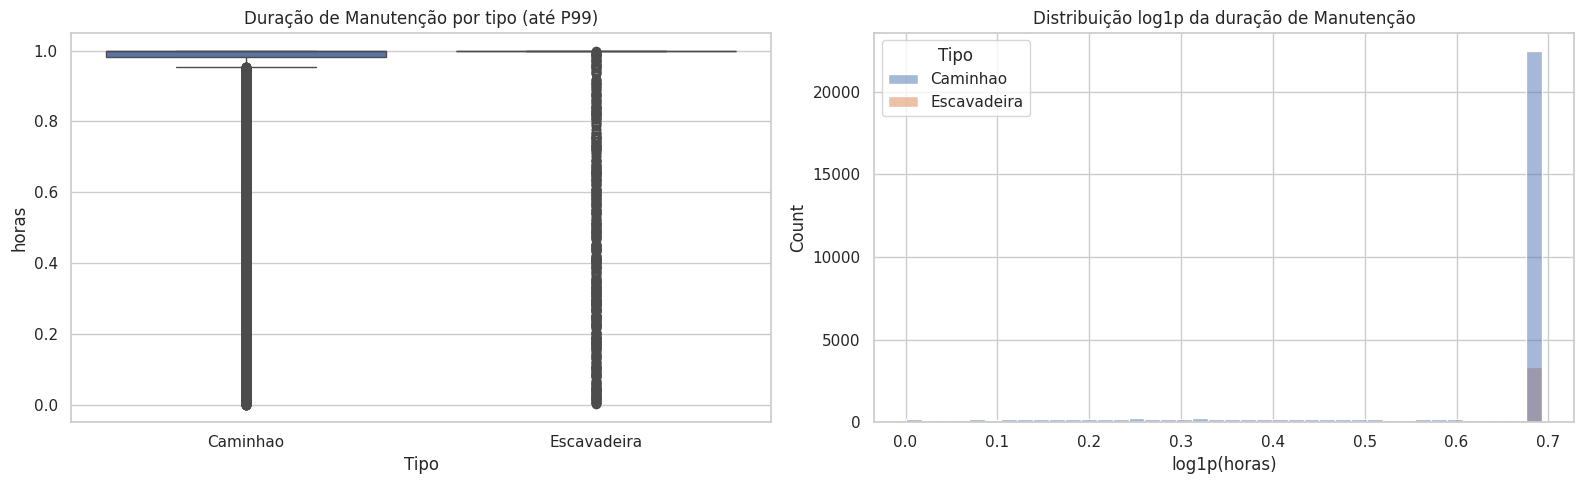

In [3]:
maintenance = query(
    '''
    SELECT
        Id AS maintenance_id,
        Tag AS TAG,
        any_value(Frota) AS Frota,
        any_value(Tipo) AS Tipo,
        Inicio AS manut_inicio,
        Fim AS manut_fim,
        date_diff('second', Inicio, Fim) / 3600.0 AS duracao_h
    FROM ap
    WHERE Classe = 'Manutenção'
    GROUP BY Id, Tag, Inicio, Fim
    ORDER BY Inicio, Tag
    '''
)
maintenance["Tipo"] = maintenance["Tipo"].replace({"Caminhão": "Caminhao"})
maintenance["split"] = split_from_time(maintenance["manut_inicio"])
maintenance = maintenance[maintenance["split"] != "fora_do_split"].copy()
maintenance["atravessa_lacuna"] = crosses_missing(maintenance["manut_inicio"], maintenance["manut_fim"])

display(maintenance.groupby(["split", "Tipo"], dropna=False).agg(
    manutencoes=("maintenance_id", "size"),
    tags=("TAG", "nunique"),
    duracao_media_h=("duracao_h", "mean"),
    duracao_mediana_h=("duracao_h", "median"),
    duracao_p75_h=("duracao_h", lambda x: x.quantile(.75)),
    duracao_p90_h=("duracao_h", lambda x: x.quantile(.90)),
    duracao_p95_h=("duracao_h", lambda x: x.quantile(.95)),
    atravessa_lacuna=("atravessa_lacuna", "sum"),
).reset_index())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.boxplot(data=maintenance[maintenance["duracao_h"] <= maintenance["duracao_h"].quantile(.99)], x="Tipo", y="duracao_h", ax=axes[0])
axes[0].set(title="Duração de Manutenção por tipo (até P99)", ylabel="horas")
sns.histplot(data=maintenance, x=np.log1p(maintenance["duracao_h"]), hue="Tipo", bins=40, ax=axes[1])
axes[1].set(title="Distribuição log1p da duração de Manutenção", xlabel="log1p(horas)")
plt.tight_layout()
plt.show()

## 3. Episódios `Is_Dont_Go`

Usa a mesma camada analítica congelada dos notebooks recentes:

- preserva dados brutos;
- remove apenas duplicatas exatas na camada analítica;
- expurga somente o loop localizado da `PE3798` em 29/06/2025 para os dois Remote PTO;
- forma episódio por `TAG + Id_Alarme` com gap de 900s.

In [4]:
start = time.time()
con.execute(
    f'''
    CREATE OR REPLACE TEMP TABLE analytic_events AS
    SELECT
        min(Id_Eventos_Telemetria) AS Id_Eventos_Telemetria_referencia,
        Data_Evento, Inicio_Turno, Fim_Turno, Dia, Localidade, TAG, Tag_Frota, Tipo,
        Nome_Operador_Anon, Matricula_Operador_Hash, Id_Alarme, Alarme,
        Id_Criticidade, Criticidade, Valor, Classe, Is_Dont_Go,
        count(*) AS ids_evento_no_grupo
    FROM tel
    WHERE NOT (
        TAG = '{LOOP_TAG}'
        AND CAST(Data_Evento AS DATE) = DATE '{LOOP_DAY.date()}'
        AND Id_Alarme IN {LOOP_ALARM_IDS}
    )
    GROUP BY
        Data_Evento, Inicio_Turno, Fim_Turno, Dia, Localidade, TAG, Tag_Frota, Tipo,
        Nome_Operador_Anon, Matricula_Operador_Hash, Id_Alarme, Alarme,
        Id_Criticidade, Criticidade, Valor, Classe, Is_Dont_Go
    '''
)

con.execute(
    f'''
    CREATE OR REPLACE TEMP TABLE alarm_sequences AS
    WITH ordered AS (
        SELECT *,
               lag(Data_Evento) OVER (
                   PARTITION BY TAG, Id_Alarme ORDER BY Data_Evento, Id_Eventos_Telemetria_referencia
               ) AS evento_anterior
        FROM analytic_events
    ), flagged AS (
        SELECT *,
               CASE
                   WHEN evento_anterior IS NULL THEN 1
                   WHEN date_diff('millisecond', evento_anterior, Data_Evento) > {SEQUENCE_GAP_SECONDS * 1000} THEN 1
                   ELSE 0
               END AS nova_sequencia
        FROM ordered
    ), numbered AS (
        SELECT *,
               sum(nova_sequencia) OVER (
                   PARTITION BY TAG, Id_Alarme
                   ORDER BY Data_Evento, Id_Eventos_Telemetria_referencia
                   ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
               ) AS numero_sequencia
        FROM flagged
    )
    SELECT
        TAG, any_value(Tag_Frota) AS Tag_Frota, any_value(Tipo) AS Tipo,
        Id_Alarme, any_value(Alarme) AS Alarme,
        numero_sequencia,
        min(Data_Evento) AS inicio,
        max(Data_Evento) AS fim,
        count(*) AS registros_analiticos,
        sum(ids_evento_no_grupo) AS registros_brutos_representados,
        max(Is_Dont_Go) AS is_dont_go
    FROM numbered
    GROUP BY TAG, Id_Alarme, numero_sequencia
    '''
)

dg_episodes = query(
    '''
    SELECT
        row_number() OVER (ORDER BY inicio, TAG, Id_Alarme, numero_sequencia) AS dg_episode_id,
        TAG, Tag_Frota, Tipo, Id_Alarme, Alarme,
        inicio AS dg_inicio,
        fim AS dg_fim,
        registros_analiticos,
        registros_brutos_representados
    FROM alarm_sequences
    WHERE is_dont_go = 1
    ORDER BY inicio, TAG
    '''
)
dg_episodes["Tipo"] = dg_episodes["Tipo"].replace({"Caminhão": "Caminhao"})
dg_episodes["conceito_textual"] = dg_episodes["Alarme"].map(normalize_alarm_name)
dg_episodes["split"] = split_from_time(dg_episodes["dg_inicio"])
dg_episodes = dg_episodes[dg_episodes["split"] != "fora_do_split"].copy()

sequence_audit = query(
    '''
    SELECT count(*) AS sequencias,
           sum(is_dont_go) AS sequencias_dont_go,
           count(DISTINCT TAG) AS tags,
           count(DISTINCT Id_Alarme) AS ids_alarme
    FROM alarm_sequences
    '''
)
sequence_audit["tempo_s"] = round(time.time() - start, 1)
display(sequence_audit)
display(dg_episodes.groupby(["split", "Tipo"], dropna=False).agg(
    episodios_dg=("dg_episode_id", "size"),
    tags=("TAG", "nunique"),
    ids_alarme=("Id_Alarme", "nunique"),
).reset_index())

,sequencias,sequencias_dont_go,tags,ids_alarme,tempo_s
0,979994,7572.0,35,1324,87.2


,split,Tipo,episodios_dg,tags,ids_alarme
0,teste,Caminhao,811,24,30
1,teste,Escavadeira,2,2,2
2,treino,Caminhao,6030,27,45
3,treino,Escavadeira,23,3,2
4,validacao,Caminhao,697,24,30
5,validacao,Escavadeira,9,1,1


## 4. `Is_Dont_Go` seguido por Manutenção

Para cada episódio `Is_Dont_Go`, medimos se existe início de `Manutenção` da mesma TAG em até
1h, 4h, 8h e 24h após o início do episódio.

Se a janela atravessa 31/05, o caso é inválido para aquela janela, pois a telemetria está ausente e
não podemos tratar ausência de alerta/manutenção como evidência.

In [5]:
con.register("dg_episodes_df", dg_episodes)
con.register("maintenance_df", maintenance)

dg_to_maintenance_rows = []
for window_h in WINDOW_HOURS:
    pairs = query(
        f'''
        SELECT
            d.dg_episode_id,
            d.TAG,
            d.Tipo,
            d.Tag_Frota,
            d.Id_Alarme,
            d.Alarme,
            d.conceito_textual,
            d.dg_inicio,
            d.dg_fim,
            d.split,
            m.maintenance_id,
            m.manut_inicio,
            m.manut_fim,
            m.duracao_h,
            date_diff('second', d.dg_inicio, m.manut_inicio) / 3600.0 AS horas_ate_manutencao,
            row_number() OVER (
                PARTITION BY d.dg_episode_id
                ORDER BY m.manut_inicio, m.maintenance_id
            ) AS rn
        FROM dg_episodes_df d
        LEFT JOIN maintenance_df m
          ON d.TAG = m.TAG
         AND m.manut_inicio >= d.dg_inicio
         AND m.manut_inicio < d.dg_inicio + INTERVAL '{window_h} hours'
        '''
    )
    first = pairs[(pairs["rn"].isna()) | (pairs["rn"] == 1)].copy()
    first["janela_h"] = window_h
    first["janela_inicio"] = first["dg_inicio"]
    first["janela_fim"] = first["dg_inicio"] + pd.to_timedelta(window_h, unit="h")
    first["janela_valida"] = ~crosses_missing(first["janela_inicio"], first["janela_fim"])
    first["teve_manutencao"] = first["maintenance_id"].notna()
    dg_to_maintenance_rows.append(first)

dg_to_maintenance = pd.concat(dg_to_maintenance_rows, ignore_index=True)

dg_manut_summary = (
    dg_to_maintenance[dg_to_maintenance["janela_valida"]]
    .groupby(["split", "Tipo", "janela_h"], dropna=False)
    .agg(
        episodios_dg=("dg_episode_id", "size"),
        episodios_com_manutencao=("teve_manutencao", "sum"),
        taxa_com_manutencao=("teve_manutencao", "mean"),
        mediana_h_ate_manutencao=("horas_ate_manutencao", "median"),
        mediana_duracao_manut_h=("duracao_h", "median"),
        p90_duracao_manut_h=("duracao_h", lambda x: x.dropna().quantile(.90) if x.notna().any() else np.nan),
    )
    .reset_index()
)
display(dg_manut_summary)

retro_dg_manut = (
    dg_to_maintenance[dg_to_maintenance["janela_valida"]]
    .groupby(["Tipo", "janela_h"], dropna=False)
    .agg(
        episodios_dg=("dg_episode_id", "size"),
        episodios_com_manutencao=("teve_manutencao", "sum"),
        taxa_com_manutencao=("teve_manutencao", "mean"),
        mediana_h_ate_manutencao=("horas_ate_manutencao", "median"),
        mediana_duracao_manut_h=("duracao_h", "median"),
    )
    .reset_index()
)
print("Retrospectivo completo, descritivo, não usar para escolher regra final:")
display(retro_dg_manut)

,split,Tipo,janela_h,episodios_dg,episodios_com_manutencao,taxa_com_manutencao,mediana_h_ate_manutencao,mediana_duracao_manut_h,p90_duracao_manut_h
0,teste,Caminhao,1,811,323,0.398274,0.321389,0.428056,1.000000
1,teste,Caminhao,4,811,511,0.630086,0.711111,0.428333,1.000000
2,teste,Caminhao,8,811,609,0.750925,0.890278,0.428889,0.899167
3,teste,Caminhao,24,811,756,0.932182,1.422361,0.447500,0.891667
4,teste,Escavadeira,1,2,2,1.000000,0.257222,1.000000,1.000000
5,teste,Escavadeira,4,2,2,1.000000,0.257222,1.000000,1.000000
6,teste,Escavadeira,8,2,2,1.000000,0.257222,1.000000,1.000000
7,teste,Escavadeira,24,2,2,1.000000,0.257222,1.000000,1.000000
8,treino,Caminhao,1,6030,1822,0.302156,0.372222,0.476667,1.000000
9,treino,Caminhao,4,6030,3064,0.508126,0.755000,0.416667,1.000000


Retrospectivo completo, descritivo, não usar para escolher regra final:


,Tipo,janela_h,episodios_dg,episodios_com_manutencao,taxa_com_manutencao,mediana_h_ate_manutencao,mediana_duracao_manut_h
0,Caminhao,1,7537,2466,0.327186,0.364722,0.472361
1,Caminhao,4,7533,4042,0.536572,0.731111,0.419444
2,Caminhao,8,7530,5103,0.677689,1.119167,0.408611
3,Caminhao,24,7526,6596,0.876428,2.232361,0.411111
4,Escavadeira,1,34,11,0.323529,0.261944,0.759444
5,Escavadeira,4,34,18,0.529412,0.579583,0.591111
6,Escavadeira,8,33,18,0.545455,0.600972,0.591111
7,Escavadeira,24,33,26,0.787879,1.812778,0.549722


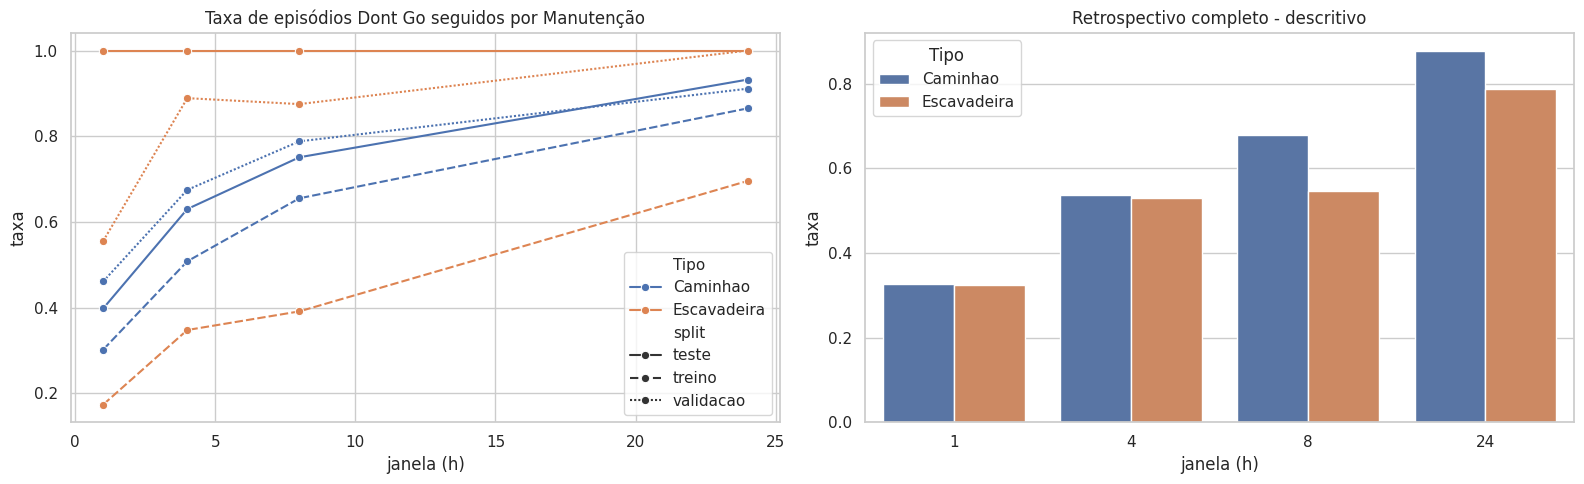

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.lineplot(data=dg_manut_summary, x="janela_h", y="taxa_com_manutencao", hue="Tipo", style="split", marker="o", ax=axes[0])
axes[0].set(title="Taxa de episódios Dont Go seguidos por Manutenção", xlabel="janela (h)", ylabel="taxa")
sns.barplot(data=retro_dg_manut, x="janela_h", y="taxa_com_manutencao", hue="Tipo", ax=axes[1])
axes[1].set(title="Retrospectivo completo - descritivo", xlabel="janela (h)", ylabel="taxa")
plt.tight_layout()
plt.show()

## 5. Manutenção precedida por `Is_Dont_Go`

Agora invertemos a pergunta: para cada manutenção, existe episódio `Is_Dont_Go` da mesma TAG nas
1h, 4h, 8h ou 24h anteriores?

Janelas retrospectivas que atravessam 31/05 também são inválidas.

In [7]:
maintenance_to_dg_rows = []
for window_h in WINDOW_HOURS:
    pairs = query(
        f'''
        SELECT
            m.maintenance_id,
            m.TAG,
            m.Tipo,
            m.Frota,
            m.manut_inicio,
            m.manut_fim,
            m.duracao_h,
            m.split,
            d.dg_episode_id,
            d.Id_Alarme,
            d.Alarme,
            d.conceito_textual,
            d.dg_inicio,
            date_diff('second', d.dg_inicio, m.manut_inicio) / 3600.0 AS horas_desde_dg,
            row_number() OVER (
                PARTITION BY m.maintenance_id
                ORDER BY d.dg_inicio DESC, d.dg_episode_id DESC
            ) AS rn
        FROM maintenance_df m
        LEFT JOIN dg_episodes_df d
          ON d.TAG = m.TAG
         AND d.dg_inicio < m.manut_inicio
         AND d.dg_inicio >= m.manut_inicio - INTERVAL '{window_h} hours'
        '''
    )
    first = pairs[(pairs["rn"].isna()) | (pairs["rn"] == 1)].copy()
    first["janela_h"] = window_h
    first["janela_inicio"] = first["manut_inicio"] - pd.to_timedelta(window_h, unit="h")
    first["janela_fim"] = first["manut_inicio"]
    first["janela_valida"] = ~crosses_missing(first["janela_inicio"], first["janela_fim"])
    first["teve_dg_anterior"] = first["dg_episode_id"].notna()
    maintenance_to_dg_rows.append(first)

maintenance_to_dg = pd.concat(maintenance_to_dg_rows, ignore_index=True)

manut_dg_summary = (
    maintenance_to_dg[maintenance_to_dg["janela_valida"]]
    .groupby(["split", "Tipo", "janela_h"], dropna=False)
    .agg(
        manutencoes=("maintenance_id", "size"),
        manut_com_dg_anterior=("teve_dg_anterior", "sum"),
        taxa_com_dg_anterior=("teve_dg_anterior", "mean"),
        duracao_mediana_h=("duracao_h", "median"),
        duracao_mediana_com_dg_h=("duracao_h", lambda x: np.nan),
    )
    .reset_index()
)

duration_by_flag = (
    maintenance_to_dg[maintenance_to_dg["janela_valida"]]
    .groupby(["split", "Tipo", "janela_h", "teve_dg_anterior"], dropna=False)
    .agg(
        manutencoes=("maintenance_id", "size"),
        duracao_media_h=("duracao_h", "mean"),
        duracao_mediana_h=("duracao_h", "median"),
        duracao_p75_h=("duracao_h", lambda x: x.quantile(.75)),
        duracao_p90_h=("duracao_h", lambda x: x.quantile(.90)),
    )
    .reset_index()
)

display(manut_dg_summary.drop(columns=["duracao_mediana_com_dg_h"]))
display(duration_by_flag)

retro_manut_dg = (
    maintenance_to_dg[maintenance_to_dg["janela_valida"]]
    .groupby(["Tipo", "janela_h"], dropna=False)
    .agg(
        manutencoes=("maintenance_id", "size"),
        manut_com_dg_anterior=("teve_dg_anterior", "sum"),
        taxa_com_dg_anterior=("teve_dg_anterior", "mean"),
    )
    .reset_index()
)
print("Retrospectivo completo, descritivo, não usar para escolher regra final:")
display(retro_manut_dg)

,split,Tipo,janela_h,manutencoes,manut_com_dg_anterior,taxa_com_dg_anterior,duracao_mediana_h
0,teste,Caminhao,1,4440,289,0.065090,1.0
1,teste,Caminhao,4,4427,496,0.112040,1.0
2,teste,Caminhao,8,4405,666,0.151192,1.0
3,teste,Caminhao,24,4273,1139,0.266557,1.0
4,teste,Escavadeira,1,652,2,0.003067,1.0
5,teste,Escavadeira,4,652,8,0.012270,1.0
6,teste,Escavadeira,8,652,16,0.024540,1.0
7,teste,Escavadeira,24,651,40,0.061444,1.0
8,treino,Caminhao,1,20982,1449,0.069059,1.0
9,treino,Caminhao,4,20982,2853,0.135974,1.0


,split,Tipo,janela_h,teve_dg_anterior,manutencoes,duracao_media_h,duracao_mediana_h,duracao_p75_h,duracao_p90_h
0,teste,Caminhao,1,False,4151,0.866201,1.000000,1.000000,1.000000
1,teste,Caminhao,1,True,289,0.491672,0.394444,0.745000,1.000000
2,teste,Caminhao,4,False,3931,0.874424,1.000000,1.000000,1.000000
3,teste,Caminhao,4,True,496,0.580032,0.543333,1.000000,1.000000
4,teste,Caminhao,8,False,3739,0.876647,1.000000,1.000000,1.000000
5,teste,Caminhao,8,True,666,0.640353,0.698889,1.000000,1.000000
6,teste,Caminhao,24,False,3134,0.884181,1.000000,1.000000,1.000000
7,teste,Caminhao,24,True,1139,0.713999,1.000000,1.000000,1.000000
8,teste,Escavadeira,1,False,650,0.921661,1.000000,1.000000,1.000000
9,teste,Escavadeira,1,True,2,1.000000,1.000000,1.000000,1.000000


Retrospectivo completo, descritivo, não usar para escolher regra final:


,Tipo,janela_h,manutencoes,manut_com_dg_anterior,taxa_com_dg_anterior
0,Caminhao,1,29820,2010,0.067404
1,Caminhao,4,29807,3848,0.129097
2,Caminhao,8,29785,5318,0.178546
3,Caminhao,24,29653,9395,0.316831
4,Escavadeira,1,4021,15,0.003730
5,Escavadeira,4,4021,34,0.008456
6,Escavadeira,8,4021,54,0.013429
7,Escavadeira,24,4020,127,0.031592


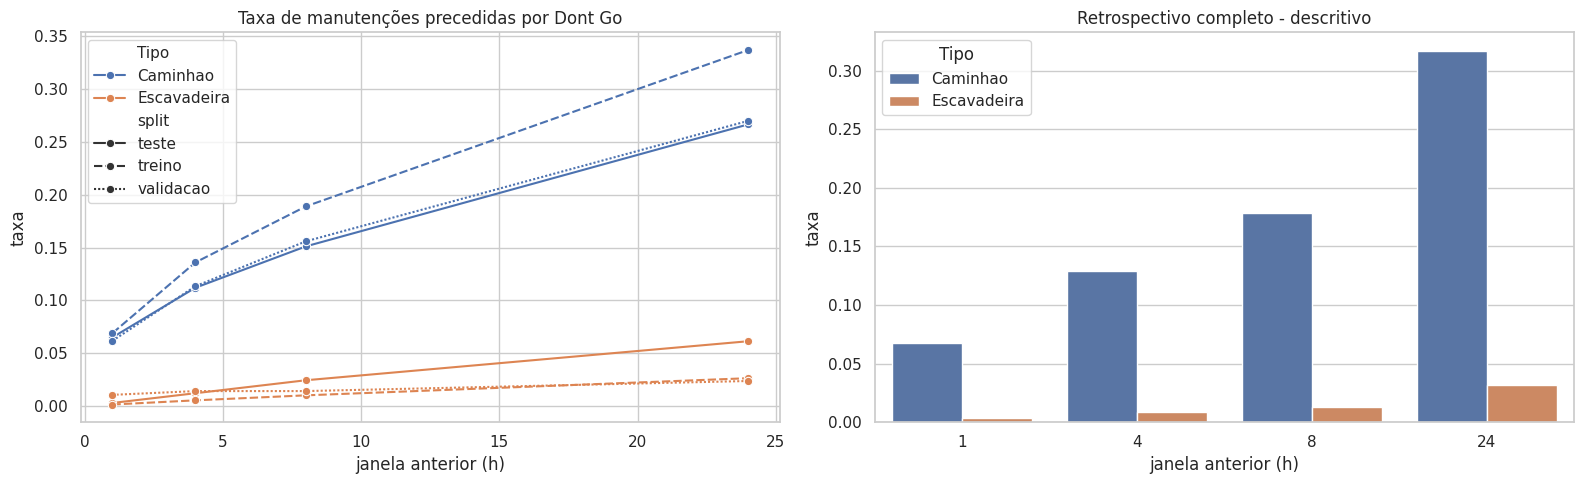

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.lineplot(data=manut_dg_summary, x="janela_h", y="taxa_com_dg_anterior", hue="Tipo", style="split", marker="o", ax=axes[0])
axes[0].set(title="Taxa de manutenções precedidas por Dont Go", xlabel="janela anterior (h)", ylabel="taxa")
sns.barplot(data=retro_manut_dg, x="janela_h", y="taxa_com_dg_anterior", hue="Tipo", ax=axes[1])
axes[1].set(title="Retrospectivo completo - descritivo", xlabel="janela anterior (h)", ylabel="taxa")
plt.tight_layout()
plt.show()

## 6. Diferença de duração: manutenção com e sem alerta anterior

,split,Tipo,janela_h,n_sem_dg,n_com_dg,mediana_sem_dg_h,mediana_com_dg_h,delta_mediana_h,p90_sem_dg_h,p90_com_dg_h
0,teste,Caminhao,1,4151,289,1.0,0.394444,-0.605556,1.0,1.000000
1,teste,Escavadeira,1,650,2,1.0,1.000000,0.000000,1.0,1.000000
2,treino,Caminhao,1,19533,1449,1.0,0.480278,-0.519722,1.0,1.000000
3,treino,Escavadeira,1,2526,4,1.0,0.920000,-0.080000,1.0,1.000000
4,validacao,Caminhao,1,4126,272,1.0,0.432083,-0.567917,1.0,1.000000
5,validacao,Escavadeira,1,830,9,1.0,0.591111,-0.408889,1.0,0.982667
6,teste,Caminhao,4,3931,496,1.0,0.543333,-0.456667,1.0,1.000000
7,teste,Escavadeira,4,644,8,1.0,1.000000,0.000000,1.0,1.000000
8,treino,Caminhao,4,18129,2853,1.0,0.716111,-0.283889,1.0,1.000000
9,treino,Escavadeira,4,2516,14,1.0,1.000000,0.000000,1.0,1.000000


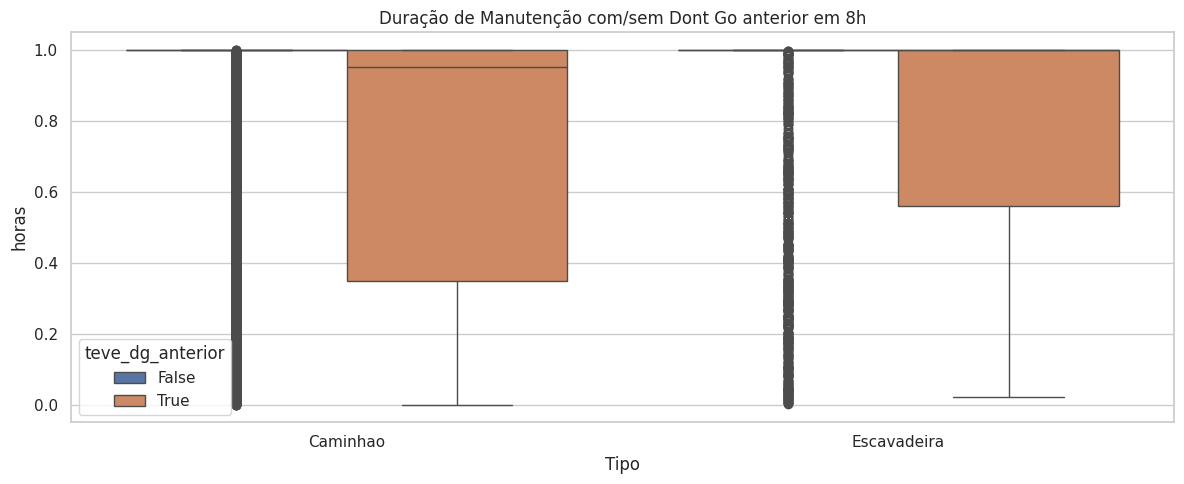

In [9]:
duration_compare = []
for window_h in WINDOW_HOURS:
    part = maintenance_to_dg[
        (maintenance_to_dg["janela_h"] == window_h)
        & (maintenance_to_dg["janela_valida"])
    ].copy()
    for (split, tipo), group in part.groupby(["split", "Tipo"], dropna=False):
        no_alert = group.loc[~group["teve_dg_anterior"], "duracao_h"]
        with_alert = group.loc[group["teve_dg_anterior"], "duracao_h"]
        duration_compare.append({
            "split": split,
            "Tipo": tipo,
            "janela_h": window_h,
            "n_sem_dg": len(no_alert),
            "n_com_dg": len(with_alert),
            "mediana_sem_dg_h": no_alert.median() if len(no_alert) else np.nan,
            "mediana_com_dg_h": with_alert.median() if len(with_alert) else np.nan,
            "delta_mediana_h": (with_alert.median() - no_alert.median()) if len(no_alert) and len(with_alert) else np.nan,
            "p90_sem_dg_h": no_alert.quantile(.90) if len(no_alert) else np.nan,
            "p90_com_dg_h": with_alert.quantile(.90) if len(with_alert) else np.nan,
        })
duration_compare = pd.DataFrame(duration_compare)
display(duration_compare)

selected_window = 8
plot_duration = maintenance_to_dg[
    (maintenance_to_dg["janela_h"] == selected_window)
    & (maintenance_to_dg["janela_valida"])
    & (maintenance_to_dg["duracao_h"] <= maintenance_to_dg["duracao_h"].quantile(.99))
].copy()
fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=plot_duration, x="Tipo", y="duracao_h", hue="teve_dg_anterior", ax=ax)
ax.set(title=f"Duração de Manutenção com/sem Dont Go anterior em {selected_window}h", ylabel="horas")
plt.tight_layout()
plt.show()

## 7. Recortes por TAG e conceito

In [10]:
window_for_detail = 8
dg_detail = dg_to_maintenance[
    (dg_to_maintenance["janela_h"] == window_for_detail)
    & (dg_to_maintenance["janela_valida"])
].copy()

tag_dg_detail = (
    dg_detail.groupby(["split", "Tipo", "TAG"], dropna=False)
    .agg(
        episodios_dg=("dg_episode_id", "size"),
        com_manutencao=("teve_manutencao", "sum"),
        taxa_com_manutencao=("teve_manutencao", "mean"),
        mediana_h_ate_manutencao=("horas_ate_manutencao", "median"),
    )
    .reset_index()
    .sort_values(["split", "Tipo", "com_manutencao", "episodios_dg"], ascending=[True, True, False, False])
)
display(tag_dg_detail.groupby(["split", "Tipo"], dropna=False).head(15))

concept_detail = (
    dg_detail.groupby(["split", "Tipo", "Id_Alarme", "conceito_textual"], dropna=False)
    .agg(
        episodios_dg=("dg_episode_id", "size"),
        tags=("TAG", "nunique"),
        com_manutencao=("teve_manutencao", "sum"),
        taxa_com_manutencao=("teve_manutencao", "mean"),
        mediana_h_ate_manutencao=("horas_ate_manutencao", "median"),
    )
    .reset_index()
    .sort_values(["split", "Tipo", "com_manutencao", "episodios_dg"], ascending=[True, True, False, False])
)
display(concept_detail.groupby(["split", "Tipo"], dropna=False).head(20))

,split,Tipo,TAG,episodios_dg,com_manutencao,taxa_com_manutencao,mediana_h_ate_manutencao
12,teste,Caminhao,CA65926,229,147,0.641921,1.323056
13,teste,Caminhao,CA65927,114,102,0.894737,1.191806
21,teste,Caminhao,CA65935,61,58,0.950820,0.939167
19,teste,Caminhao,CA65933,73,49,0.671233,0.630556
22,teste,Caminhao,CA65936,39,37,0.948718,0.475278
6,teste,Caminhao,CA65909,39,33,0.846154,1.098889
14,teste,Caminhao,CA65928,25,24,0.960000,0.715139
9,teste,Caminhao,CA65921,35,23,0.657143,1.693889
0,teste,Caminhao,CA5926,23,22,0.956522,0.660278
1,teste,Caminhao,CA5927,28,19,0.678571,0.598333


,split,Tipo,Id_Alarme,conceito_textual,episodios_dg,tags,com_manutencao,taxa_com_manutencao,mediana_h_ate_manutencao
28,teste,Caminhao,84613669,TRANSMISSION OIL LEVEL ACTIVE,178,17,161,0.904494,0.524722
19,teste,Caminhao,84608753,ENGINE COOLANT LEVEL ACTIVE,128,13,99,0.773438,2.140278
20,teste,Caminhao,84609435,RIGHT FRONT BRAKE TEMPERATURE ACTIVE,160,1,85,0.531250,2.384722
23,teste,Caminhao,84609797,ENGINE COOLANT LEVEL ACTIVE,29,9,28,0.965517,0.356389
25,teste,Caminhao,84609807,AFTERCOOLER LEVEL ACTIVE,28,10,27,0.964286,0.226111
1,teste,Caminhao,84607073,ENGINE COOLANT LEVEL ACTIVE,24,9,23,0.958333,0.413611
0,teste,Caminhao,84607069,AFTERCOOLER LEVEL ACTIVE,21,11,21,1.000000,0.304444
12,teste,Caminhao,84608399,LEFT REAR BRAKE TEMPERATURE ACTIVE,33,11,18,0.545455,1.935278
2,teste,Caminhao,84607105,PARKING BRAKE ACTIVE,19,6,17,0.894737,0.687222
27,teste,Caminhao,84609911,CRANKCASE PRESSURE ACTIVE,41,2,16,0.390244,3.211806


## 8. Leitura auditada

Ao consolidar:

1. distinguir retrospectivo completo de decisão temporal;
2. reportar `p_acao_confirmada` observável como taxa de episódio `Is_Dont_Go` seguido por manutenção;
3. reportar também o inverso: taxa de manutenção precedida por `Is_Dont_Go`;
4. não chamar associação de causalidade;
5. manter janelas atravessando 31/05 fora das taxas.

Possíveis próximos passos:

- se a associação for fraca, manter modelo como recorrência da flag;
- se a associação for forte em algum recorte, testar target operacional derivado de manutenção;
- se a associação variar por TAG/conceito, avaliar target segmentado ou regras auxiliares.